#import all libraries

In [94]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score



#load Dataset

In [95]:
df=pd.read_csv('task.csv')

In [96]:
df.head()

,Customer ID,Login Freq,subscription plan,MonthlyPayment,Usage hours,Support Tickets,Spending Category
0,1,18,pREMIUM,1448,56,5,High
1,2,17,pREMIUM,1187,62,6,hIGH
2,3,13,sTANDARD,609,22,1,MEDIUM
3,4,4,bASIC,241,7,1,low
4,5,18,premium,1154,61,3,High


#uppercase to lowercase & remove special character


In [97]:
df[['subscription plan', 'Spending Category']] = df[['subscription plan', 'Spending Category']].apply(lambda x: x.str.lower())

In [98]:
df.head()

,Customer ID,Login Freq,subscription plan,MonthlyPayment,Usage hours,Support Tickets,Spending Category
0,1,18,premium,1448,56,5,high
1,2,17,premium,1187,62,6,high
2,3,13,standard,609,22,1,medium
3,4,4,basic,241,7,1,low
4,5,18,premium,1154,61,3,high


#check null value

In [99]:
df.isna().sum()

,0
Customer ID,0
Login Freq,0
subscription plan,16
MonthlyPayment,0
Usage hours,0
Support Tickets,0
Spending Category,12


#drop null value


In [100]:
df = df.dropna()

In [101]:
df.isna().sum()

,0
Customer ID,0
Login Freq,0
subscription plan,0
MonthlyPayment,0
Usage hours,0
Support Tickets,0
Spending Category,0


#LabelEncoder object creation

In [102]:
le=LabelEncoder()

In [103]:
cols = ['subscription plan', 'Spending Category']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [104]:
df.head()

,Customer ID,Login Freq,subscription plan,MonthlyPayment,Usage hours,Support Tickets,Spending Category
0,1,18,1,1448,56,5,0
1,2,17,1,1187,62,6,0
2,3,13,2,609,22,1,2
3,4,4,0,241,7,1,1
4,5,18,1,1154,61,3,0


#Feature and Target split

In [105]:
x=df.drop('Spending Category',axis=1)
y=df['Spending Category']

#Train test split

In [106]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,random_state=42)

#LogisticRegression object creation

In [107]:
lr=LogisticRegression()

#Model Training

In [108]:
model=lr.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Prediction

In [109]:
y_pred = model.predict(xtest)

#New data prediction + Label decoding (inverse transform)

In [110]:
new_data = [[3,	13,	2,	609,	22,	1]]


prediction = model.predict(new_data)

le.inverse_transform(prediction)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['medium'], dtype=object)

#accuracy score Check

In [111]:
accuracy = accuracy_score(ytest, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9807692307692307


#f1 score Check

In [112]:

print(f1_score(ytest, y_pred, average='weighted'))

0.9808369924648995


#Confusion Matrix

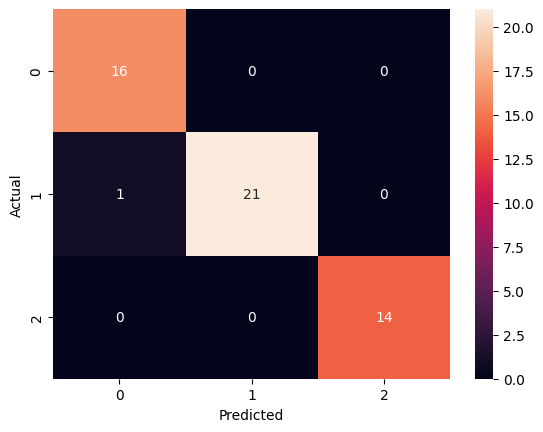

In [113]:
cm = confusion_matrix(ytest, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()